In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    count = 0
    for filename in filenames:
        if dirname == "/kaggle/input/yahoo-qa-preprocessed" and count == 0:
            print()
            count += 1
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/artifacts/skipgram_word2vec.model.syn1neg.npy
/kaggle/input/artifacts/skipgram_embedding_matrix.npy
/kaggle/input/artifacts/glove_embedding_matrix.npy
/kaggle/input/artifacts/skipgram_word2vec.model.wv.vectors.npy
/kaggle/input/artifacts/tokenizer.pkl
/kaggle/input/artifacts/skipgram_word2vec.model

/kaggle/input/yahoo-qa-preprocessed/uptaded_train_preprocessed.csv
/kaggle/input/yahoo-qa-preprocessed/uptaded_test_preprocessed.csv


# Imports

In [2]:
import os
import joblib


import numpy as np
import pandas as pd

import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Bidirectional, Dense, Dropout

2025-09-09 13:24:19.708863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757424259.732126    2721 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757424259.739007    2721 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# NN Models with Embeddings

## 1. Load preprocessed CSVs

In [3]:
train_df = pd.read_csv("/kaggle/input/yahoo-qa-preprocessed/uptaded_train_preprocessed.csv")
test_df  = pd.read_csv("/kaggle/input/yahoo-qa-preprocessed/uptaded_test_preprocessed.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (280003, 29)
Test shape: (59999, 29)


## 2. Load tokenizer

In [4]:
with open("/kaggle/input/artifacts/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

## 4. Encode labels

In [5]:
train_texts = train_df["clean_text_basic"].astype(str).tolist()
test_texts  = test_df["clean_text_basic"].astype(str).tolist()

# Labels
y_train = train_df["Class"].values
y_test  = test_df["Class"].values

# Encode labels to integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test  = label_encoder.transform(y_test)

# Save encoder
os.makedirs("dump_artifacts", exist_ok=True)

# Save label encoder
joblib.dump(label_encoder, "dump_artifacts/label_encoder.pkl")

['dump_artifacts/label_encoder.pkl']

## 4. Convert Text to Sequences and Add Padding

In [6]:
MAX_LEN = 200

X_train = tokenizer.texts_to_sequences(train_texts)
X_test  = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test  = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", len(y_train), "y_test:", len(y_test))



X_train: (280003, 200) X_test: (59999, 200) y_train: 280003 y_test: 59999


## 5. Train/Validation split (only on train data)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (252002, 200) Validation: (28001, 200) Test: (59999, 200)


## 5. Load embeddings

In [8]:
embedding_matrix_glove    = np.load("/kaggle/input/artifacts/glove_embedding_matrix.npy")
embedding_matrix_skipgram = np.load("/kaggle/input/artifacts/skipgram_embedding_matrix.npy")

print("Glove shape:", embedding_matrix_glove.shape)
print("Skipgram shape:", embedding_matrix_skipgram.shape)

Glove shape: (100000, 200)
Skipgram shape: (100000, 200)


# Utility Functions

## 1. Utility: Build model

In [ ]:
def build_model(rnn_type="LSTM", bidirectional=False, embedding_matrix=None,
                max_len=200, num_classes=None, trainable=False):
    model = Sequential()
    
    # Embedding Layer
    vocab_size, emb_dim = embedding_matrix.shape
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=trainable
    ))
    
    # RNN Layer
    if rnn_type == "LSTM":
        rnn_layer = LSTM(128, return_sequences=False)
    elif rnn_type == "GRU":
        rnn_layer = GRU(128, return_sequences=False)
    elif rnn_type == "SimpleRNN":
        rnn_layer = SimpleRNN(128, return_sequences=False)
    else:
        raise ValueError("Invalid rnn_type")
    
    if bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)
    
    # Dense layers
    model.add(Dropout(0.5))
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))
    
    # Compile
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    
    return model

## 2. Utility: Plot training history

In [ ]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    
    plt.show()

## 3. Utility: Evaluate model

In [ ]:
def evaluate_model(model, X_test, y_test, label_encoder, title="Model"):
    y_pred = model.predict(X_test, batch_size=128)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    acc = accuracy_score(y_test, y_pred_classes)
    f1  = f1_score(y_test, y_pred_classes, average="weighted")
    
    print(f"{title} — Accuracy: {acc:.4f}, F1-score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))
    
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
    plt.title(f"{title} — Confusion Matrix")
    plt.show()
    
    return acc, f1


In [ ]:
BATCH_SIZE = 128
EPOCHS = 10
MAX_LEN = X_train.shape[1]
NUM_CLASSES = len(np.unique(y_train))

# Utility for DNN, SimpleRNN, GRU

In [14]:
def evaluate_model_1(model, X_test, y_test, class_names, title):
    print(f"--- Evaluation for {title} ---")
    
    # Get model predictions (probabilities)
    y_pred = model.predict(X_test)
    
    # Convert predictions from probabilities to class indices
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # --- THIS IS THE FIX ---
    # Convert one-hot encoded y_test back to class indices
    if y_test.ndim == 2: # Check if y_test is one-hot encoded
        y_test_classes = np.argmax(y_test, axis=1)
    else:
        y_test_classes = y_test # It's already in the correct format
    # ----------------------
    
    # Now, calculate metrics using the corrected y_test_classes
    acc = accuracy_score(y_test_classes, y_pred_classes)
    f1_weighted = f1_score(y_test_classes, y_pred_classes, average="weighted")
    f1_macro = f1_score(y_test_classes, y_pred_classes, average="macro")

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}\n")

    # Display classification report
    print("Classification Report:")
    print(classification_report(y_test_classes, y_pred_classes, target_names=class_names))

    # Display confusion matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [15]:
# --- DEBUGGING CELL ---
print(f"Shape of y_train before encoding: {y_train.shape}")
print(f"Shape of y_val before encoding: {y_val.shape}")
print(f"Shape of y_test before encoding: {y_test.shape}")

Shape of y_train before encoding: (252002, 10)
Shape of y_val before encoding: (28001, 10)
Shape of y_test before encoding: (59999, 10)


In [16]:
from tensorflow.keras.utils import to_categorical
import numpy as np

# Check if y_train is a 1D array before one-hot encoding
if len(y_train.shape) == 1:
    print("Labels are 1D. Performing one-hot encoding...")
    num_classes = len(np.unique(y_train))
    y_train = to_categorical(y_train, num_classes)
    y_val = to_categorical(y_val, num_classes)
    y_test = to_categorical(y_test, num_classes)
else:
    print("Labels are already one-hot encoded. Skipping encoding.")

# --- The rest of your code ---
MAX_SEQUENCE_LENGTH = X_train.shape[1]
num_classes = y_train.shape[1]
EPOCHS = 10
BATCH_SIZE = 32


def run_experiment_1(build_fn, embedding_matrix, emb_name, model_name):
    print(f"\n==== Training {model_name} with {emb_name} Embeddings ====\n")
    model = build_fn(embedding_matrix, MAX_SEQUENCE_LENGTH, num_classes)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    class_names = label_encoder.classes_
    evaluate_model_1(model, X_test, y_test, class_names, f"{model_name} ({emb_name})")
    return history, model


Labels are already one-hot encoded. Skipping encoding.


# DNN (dense feed-forward)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout


def build_dnn_model(embedding_matrix, max_len, num_classes, embedding_dim=200):
    model = Sequential([
        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False
        ),
        GlobalAveragePooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

## DNN GloVe


==== Training DNN with GloVe Embeddings ====



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.2393 - loss: 2.0865 - val_accuracy: 0.4606 - val_loss: 1.6531
Epoch 2/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.3763 - loss: 1.7938 - val_accuracy: 0.4768 - val_loss: 1.5955
Epoch 3/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4081 - loss: 1.7219 - val_accuracy: 0.5108 - val_loss: 1.5044
Epoch 4/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4234 - loss: 1.6804 - val_accuracy: 0.5030 - val_loss: 1.5016
Epoch 5/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.4415 - loss: 1.6384 - val_accuracy: 0.5210 - val_loss: 1.4302
Epoch 6/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4526 - loss: 1.6056 - val_accuracy: 0.5519 - val_loss: 1.4153
Epoch 7/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4639 - loss: 1.5841 - val_accuracy: 0.5295 - val_loss: 1.4206
Epoch 8/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4724 - loss: 1

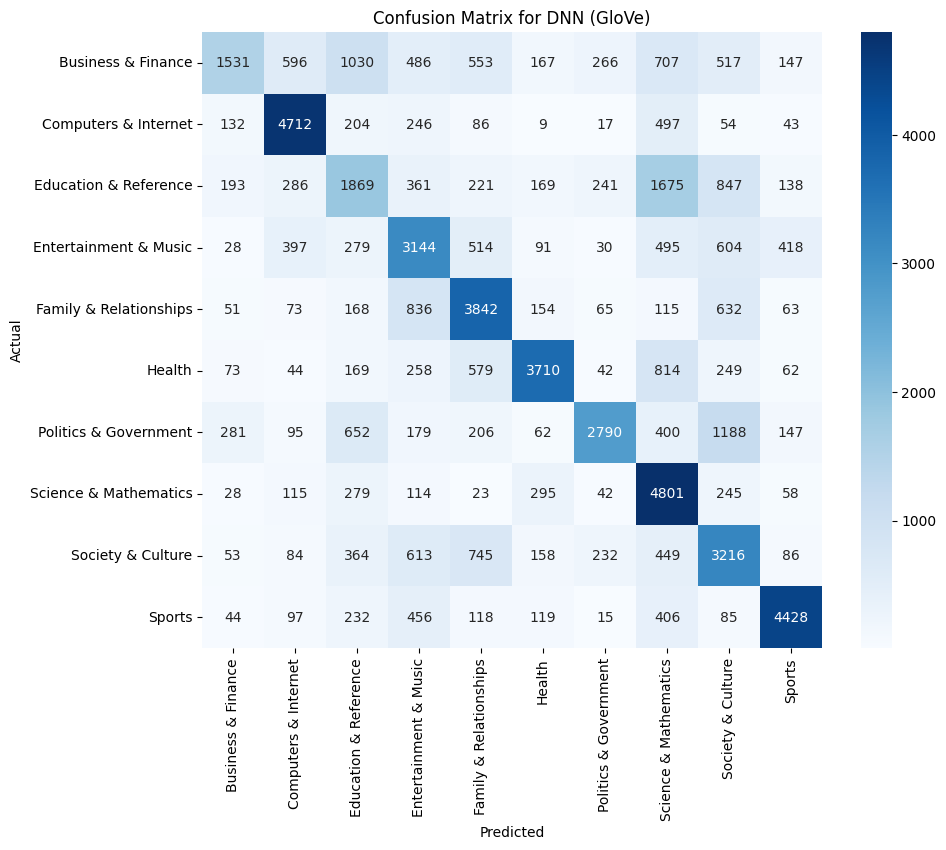

In [17]:
# Run DNN with both embeddings
dnn_history_glove, dnn_glove = run_experiment_1(
    build_dnn_model, embedding_matrix_glove, "GloVe", "DNN"
)


## DNN Skip-Gram


==== Training DNN with Skip-gram Embeddings ====



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.2059 - loss: 2.1438 - val_accuracy: 0.4072 - val_loss: 1.7222
Epoch 2/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.3344 - loss: 1.8697 - val_accuracy: 0.4004 - val_loss: 1.6782
Epoch 3/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.3661 - loss: 1.7927 - val_accuracy: 0.4893 - val_loss: 1.5932
Epoch 4/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.3871 - loss: 1.7480 - val_accuracy: 0.5210 - val_loss: 1.4849
Epoch 5/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4015 - loss: 1.7175 - val_accuracy: 0.5216 - val_loss: 1.5214
Epoch 6/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4087 - loss: 1.6996 - val_accuracy: 0.4954 - val_loss: 1.4918
Epoch 7/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4232 - loss: 1.6709 - val_accuracy: 0.4679 - val_loss: 1.5285
Epoch 8/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4302 - loss: 1

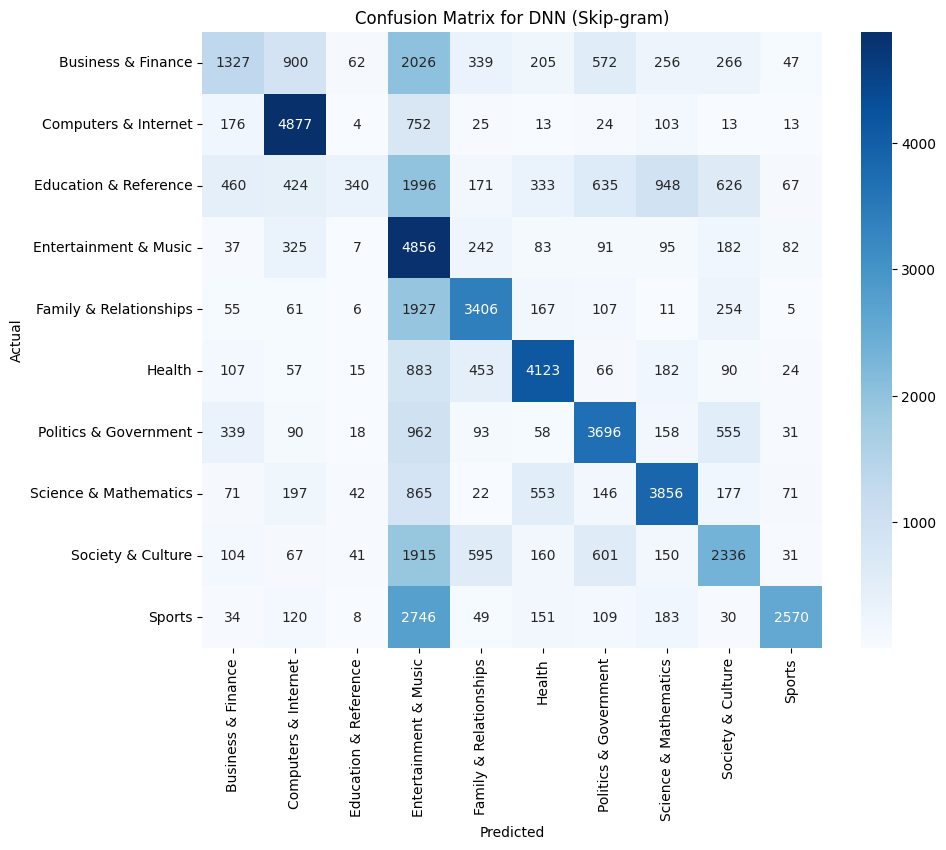

In [18]:
dnn_history_skip, dnn_skip = run_experiment_1(
    build_dnn_model, embedding_matrix_skipgram, "Skip-gram", "DNN"
)

# SimpleRNN

In [19]:
# -----------------------------
# Simple RNN
# -----------------------------
from tensorflow.keras.layers import SimpleRNN

def build_simple_rnn_model(embedding_matrix, max_len, num_classes, embedding_dim=200):
    model = Sequential([
        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False
        ),
        SimpleRNN(128, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model


## SimpleRNN (GloVe)


==== Training SimpleRNN with GloVe Embeddings ====



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 132s 16ms/step - accuracy: 0.1078 - loss: 2.3114 - val_accuracy: 0.1185 - val_loss: 2.2868
Epoch 2/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1154 - loss: 2.2907 - val_accuracy: 0.1620 - val_loss: 2.2158
Epoch 3/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1228 - loss: 2.2819 - val_accuracy: 0.1176 - val_loss: 2.2869
Epoch 4/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1143 - loss: 2.2905 - val_accuracy: 0.1171 - val_loss: 2.2816
Epoch 5/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1178 - loss: 2.2866 - val_accuracy: 0.1184 - val_loss: 2.2799
Epoch 6/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1177 - loss: 2.2836 - val_accuracy: 0.1188 - val_loss: 2.2819
Epoch 7/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1207 - loss: 2.2809 - val_accuracy: 0.1725 - val_loss: 2.1578
Epoch 8/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


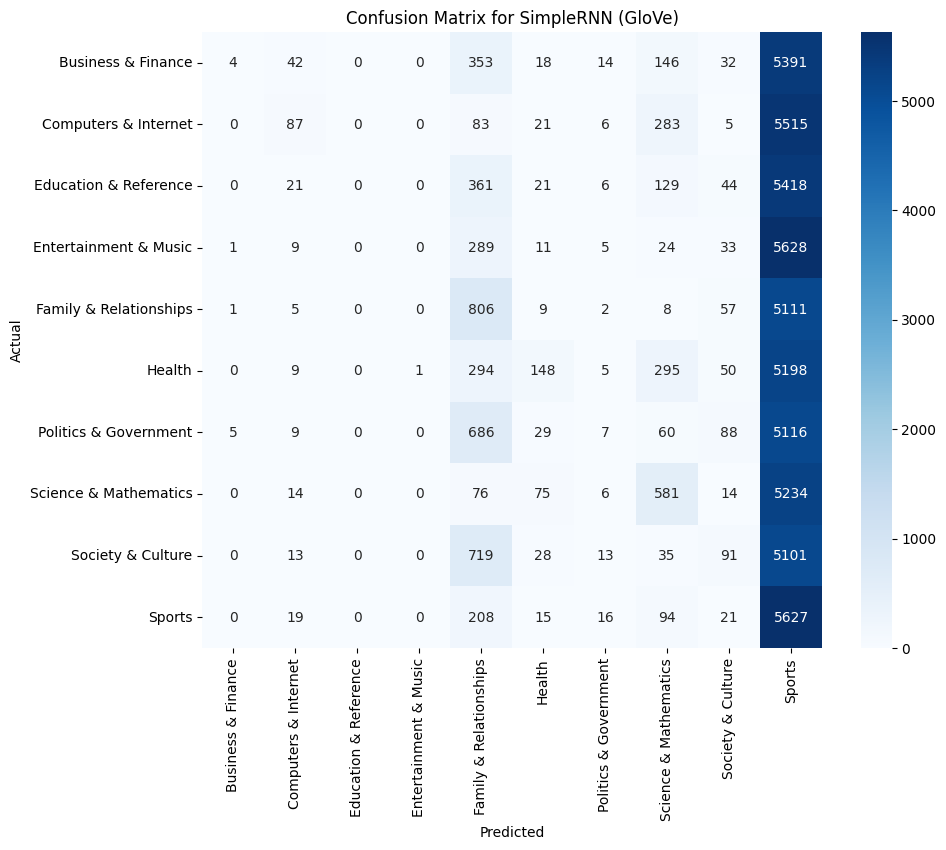

In [20]:
# Run SimpleRNN with both embeddings
simple_rnn_history_glove, simple_rnn_glove = run_experiment_1(
    build_simple_rnn_model, embedding_matrix_glove, "GloVe", "SimpleRNN"
)



## SimpleRNN (Skip-Gram)


==== Training SimpleRNN with Skip-gram Embeddings ====



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 133s 16ms/step - accuracy: 0.1056 - loss: 2.3143 - val_accuracy: 0.1105 - val_loss: 2.2964
Epoch 2/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1098 - loss: 2.2986 - val_accuracy: 0.1105 - val_loss: 2.2955
Epoch 3/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1091 - loss: 2.2984 - val_accuracy: 0.1080 - val_loss: 2.2910
Epoch 4/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1084 - loss: 2.2960 - val_accuracy: 0.1137 - val_loss: 2.2932
Epoch 5/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1123 - loss: 2.2941 - val_accuracy: 0.1114 - val_loss: 2.2896
Epoch 6/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 0.1127 - loss: 2.2924 - val_accuracy: 0.1187 - val_loss: 2.2780
Epoch 7/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 127s 16ms/step - accuracy: 0.1181 - loss: 2.2826 - val_accuracy: 0.1148 - val_loss: 2.2843
Epoch 8/10
7876/7876 ━━━━━━━━━━━━━━━━━━━━ 126s 16ms/step - accuracy: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


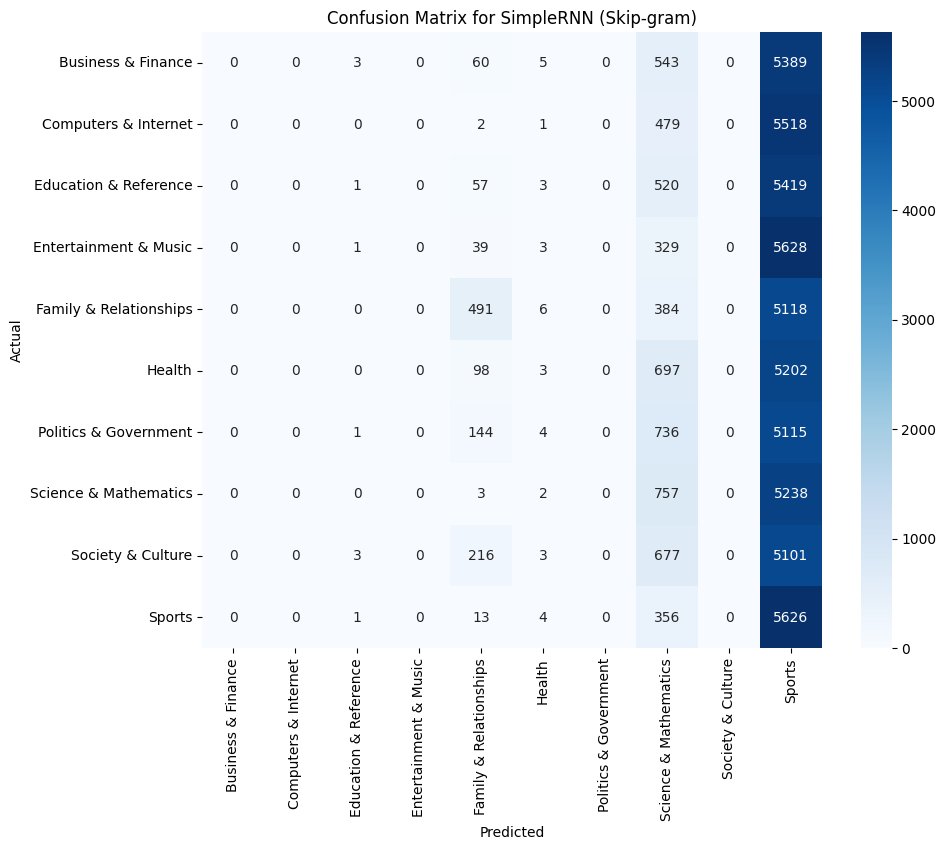

In [21]:
simple_rnn_history_skip, simple_rnn_skip = run_experiment_1(
    build_simple_rnn_model, embedding_matrix_skipgram, "Skip-gram", "SimpleRNN"
)

# GRU

In [22]:
# -----------------------------
# GRU
# -----------------------------
from tensorflow.keras.layers import GRU

def build_gru_model(embedding_matrix, max_len, num_classes, embedding_dim=200):
    model = Sequential([
        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False
        ),
        GRU(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

## GRU (GloVe)

In [ ]:
# Run GRU with both embeddings
gru_history_glove, gru_glove = run_experiment_1(
    build_gru_model, embedding_matrix_glove, "GloVe", "GRU"
)


==== Training GRU with GloVe Embeddings ====



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
3075/7876 ━━━━━━━━━━━━━━━━━━━━ 32:14 403ms/step - accuracy: 0.2404 - loss: 2.0327

## GRU (Skip-Gram)

In [ ]:
gru_history_skip, gru_skip = run_experiment_1(
    build_gru_model, embedding_matrix_skipgram, "Skip-gram", "GRU"
)